# Project Business Statistics: E-news Express

**Marks: 60**

## Define Problem Statement and Objectives


## Problem Statement
The objective of this project is to analyze user engagement with the new and existing landing pages of E-news Express to determine if the new design leads to higher user engagement and conversion rates.

## Objectives
- To determine if users spend more time on the new landing page compared to the existing one.
- To assess if the new landing page has a higher conversion rate than the existing one.
- To investigate if the conversion rate depends on the preferred language of the user.
- To explore if the time spent on the new landing page is consistent across users of different languages.

## Import all the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from statsmodels.stats.proportion import proportions_ztest

## Reading the Data into a DataFrame

In [2]:
df = pd.read_csv('abtest.csv')

## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [3]:
df.head()
df.tail()
df.shape
df.describe()
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


0

### Univariate Analysis

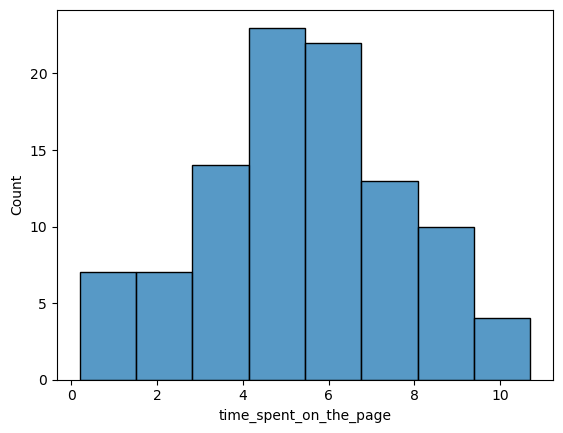

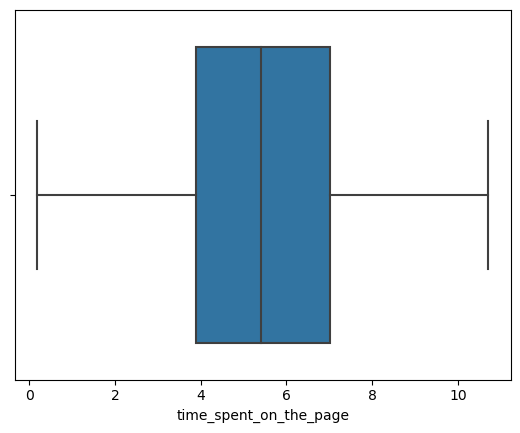

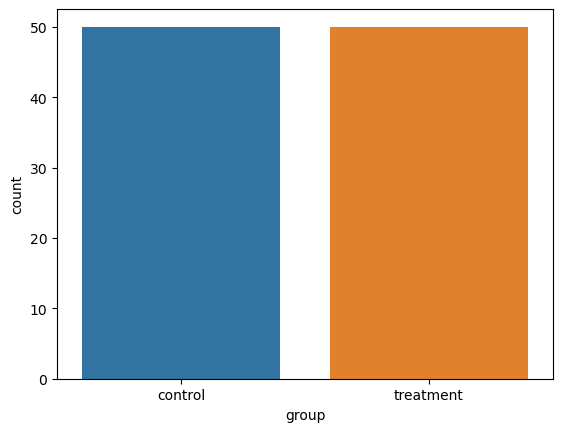

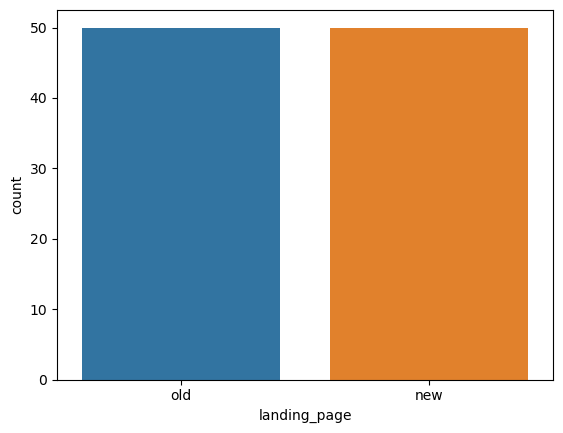

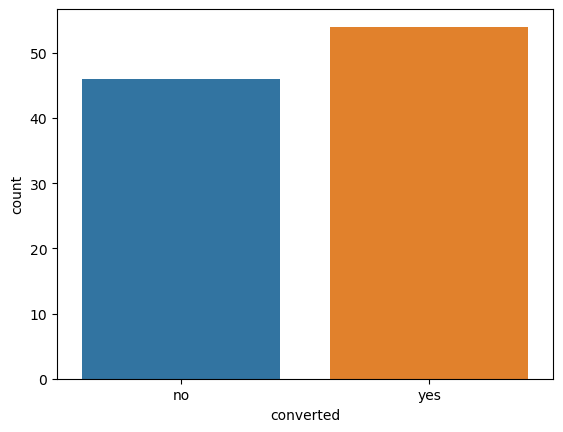

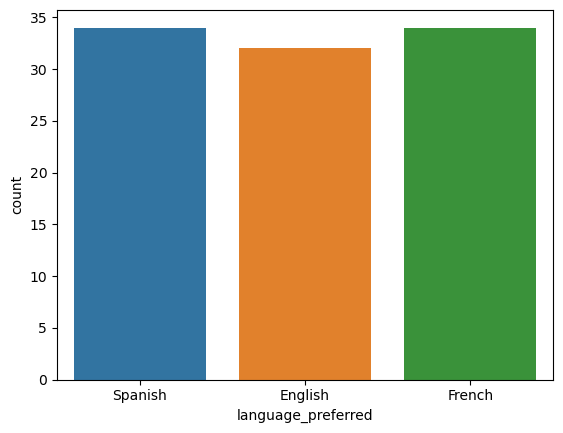

In [4]:
# For numerical data 'time_spent_on_the_page', we can use histograms and boxplots to understand the distribution.
# For categorical data like 'group', 'landing_page', 'converted', and 'language_preferred', we can use value_counts() and countplots to understand the distribution of categories.


sns.histplot(data=df, x='time_spent_on_the_page')
plt.show()

sns.boxplot(data=df, x='time_spent_on_the_page')
plt.show()

sns.countplot(data=df, x='group')
plt.show()

sns.countplot(data=df, x='landing_page')
plt.show()

sns.countplot(data=df, x='converted')
plt.show()

sns.countplot(data=df, x='language_preferred')
plt.show()

### Bivariate Analysis

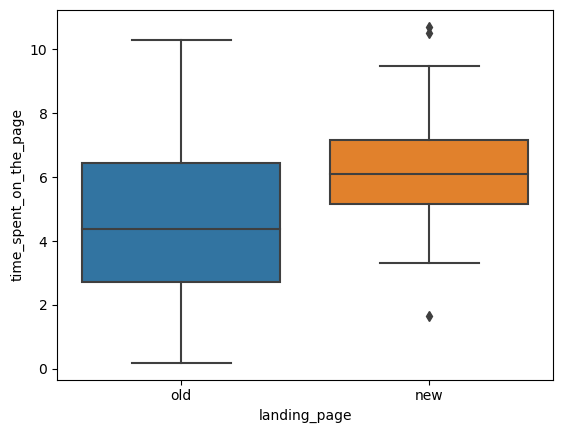

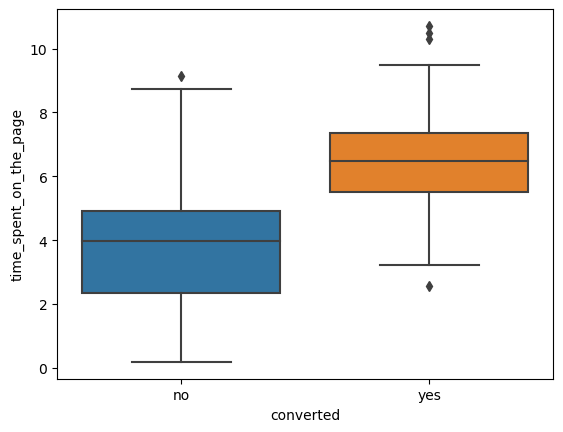

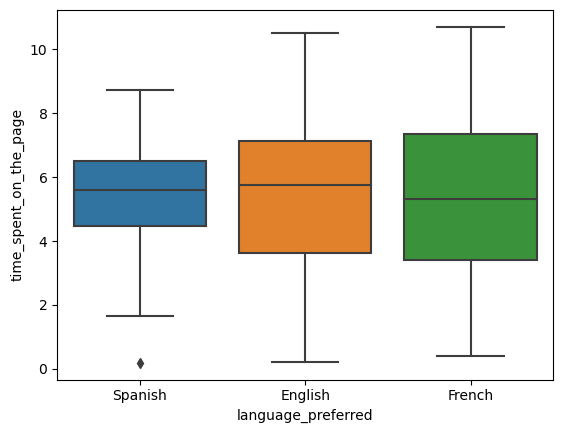

In [5]:
## Bivariate Analysis

# To examine the relationship between the 'landing_page' and 'time_spent_on_the_page', we can use boxplots.
# To explore the relationship between 'converted' status and 'time_spent_on_the_page', boxplots can again be useful.
# To see if there is any observable difference in 'time_spent_on_the_page' across different 'language_preferred' groups, boxplots can be used as well.


sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page')
plt.show()

sns.boxplot(data=df, x='converted', y='time_spent_on_the_page')
plt.show()

sns.boxplot(data=df, x='language_preferred', y='time_spent_on_the_page')
plt.show()

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

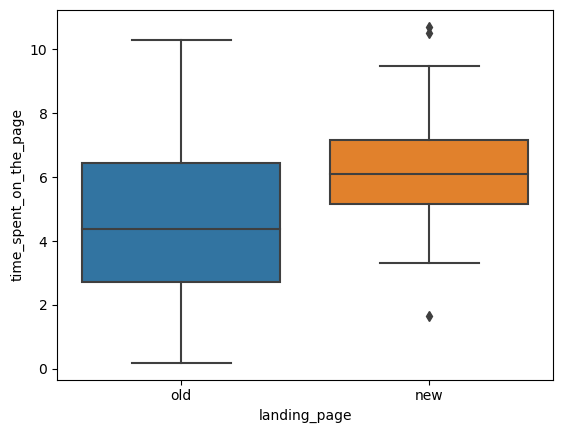

In [6]:
## 1. Time Spent on New vs. Old Landing Page

### Perform Visual Analysis

sns.boxplot(x='landing_page', y='time_spent_on_the_page', data=df)
plt.show()

### Step 1: Define the null and alternate hypotheses

$H_0$: The mean time spent on the new landing page is less than or equal to the mean time spent on the existing landing page.

$H_a$: The mean time spent on the new landing page is greater than the mean time spent on the existing landing page.

### Step 2: Select Appropriate test

For comparing two independent sample means, the appropriate test is an Independent Samples t-test.

### Step 3: Decide the significance level

The significance level is set at $\alpha = 0.05$.

### Step 4: Collect and prepare data

In [7]:
time_spent_new = df[df['landing_page'] == 'new']['time_spent_on_the_page']
time_spent_old = df[df['landing_page'] == 'old']['time_spent_on_the_page']

### Step 5: Calculate the p-value

In [8]:
from scipy.stats import ttest_ind
test_stat, p_value = ttest_ind(time_spent_new, time_spent_old, equal_var=False, alternative='greater')

### Step 6: Compare the p-value with $\alpha$

In [9]:
if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

Reject the null hypothesis


### Step 7:  Draw inference

The statistical analysis conducted through an Independent Samples t-test suggests that there is a significant difference in the time spent on the new landing page compared to the old one. Since we have rejected the null hypothesis, we can infer that the new landing page design is more effective at keeping potential subscribers engaged. The increased time spent on the page could be a result of better content, more appealing visuals, or improved layout, indicating a successful redesign from a user engagement perspective.

**A similar approach can be followed to answer the other questions.**

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

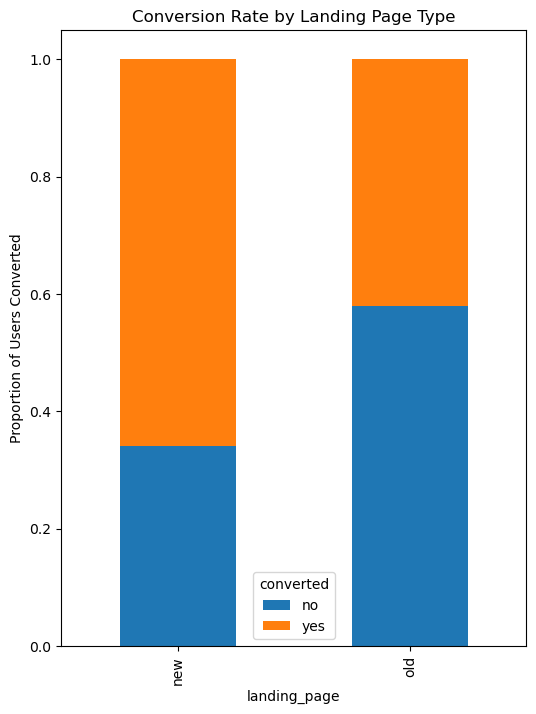

In [10]:
pd.crosstab(df['landing_page'], df['converted'], normalize='index').plot(kind="bar", figsize=(6,8), stacked=True)
plt.title('Conversion Rate by Landing Page Type')
plt.ylabel('Proportion of Users Converted')
plt.show()

### Step 1: Define the null and alternate hypotheses

𝐻0
: The mean time spent on the new landing page is less than or equal to the mean time spent on the existing landing page.

𝐻𝑎
: The mean time spent on the new landing page is greater than the mean time spent on the existing landing page.

### Step 2: Select Appropriate test

The z-test for comparing two proportions is appropriate since we are comparing the proportion of conversions between two independent groups.

### Step 3: Decide the significance level

The significance level is set at  𝛼=0.05.

### Step 4: Collect and Prepare Data

In [11]:
# Calculate the number of users who converted on each type of landing page
new_converted = df[(df['landing_page'] == 'new') & (df['converted'] == 'yes')].shape[0]
old_converted = df[(df['landing_page'] == 'old') & (df['converted'] == 'yes')].shape[0]

# Total users who received each type of landing page
n_new = df[df['landing_page'] == 'new'].shape[0]
n_old = df[df['landing_page'] == 'old'].shape[0]

### Step 5: Calculate the p-value

In [12]:
from statsmodels.stats.proportion import proportions_ztest

# Applying the z-test for two proportions
test_stat, p_value = proportions_ztest([new_converted, old_converted], [n_new, n_old], alternative='larger')
print(f'Test Statistic: {test_stat}, p-value: {p_value}')


Test Statistic: 2.4077170617153842, p-value: 0.008026308204056278


### Step 6: Compare p-value with $\alpha$

In [13]:
if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

Reject the null hypothesis


### Step 7:  Draw inference

If the null hypothesis is rejected, it implies that the conversion rate for the new landing page is statistically significantly greater than that for the old landing page. This suggests that the changes made to the landing page are effective in enhancing user conversion. Conversely, if we fail to reject the null hypothesis, it indicates that the new landing page does not perform better than the old one in terms of converting users.

The findings should be considered alongside other metrics and qualitative feedback to make informed decisions about whether to implement the new landing page across the broader user base. Further analysis could also explore specific elements of the page that users interact with most to refine the design further.

## 3. Is the conversion and preferred language are independent or related?

### Perform Visual Analysis

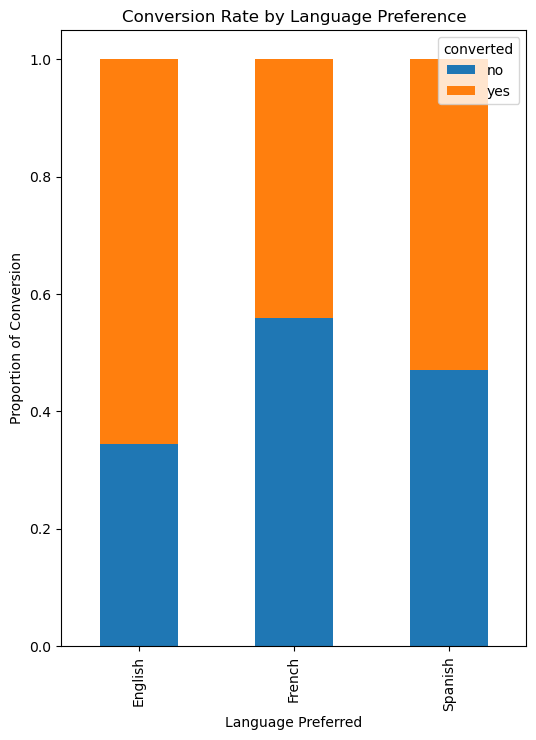

In [14]:
pd.crosstab(df['language_preferred'], df['converted'], normalize='index').plot(kind="bar", figsize=(6,8), stacked=True)
plt.title("Conversion Rate by Language Preference")
plt.xlabel("Language Preferred")
plt.ylabel("Proportion of Conversion")
plt.show()

### Step 1: Define the null and alternate hypotheses

𝐻0: Conversion status and preferred language are independent (no relationship).

𝐻𝑎: Conversion status and preferred language are dependent (there is a relationship).

### Step 2: Select Appropriate test

For assessing the relationship between two categorical variables, the Chi-square test of independence is the most appropriate.

### Step 3: Decide the significance level

The significance level is set at  𝛼=0.05.

### Step 4: Collect and Prepare Data

In [15]:
contingency_table = pd.crosstab(df['language_preferred'], df['converted'])

### Step 5: Calculate the p-value

In [16]:
from scipy.stats import chi2_contingency
chi2, p_value, dof, exp_freq = chi2_contingency(contingency_table)

### Step 6: Compare p-value with $\alpha$

In [17]:
if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

Fail to reject the null hypothesis


### Step 7:  Draw inference

Given that we failed to reject the null hypothesis in our analysis, we infer that there is no significant association between language preference and conversion status on the landing page. This outcome suggests that while language customization might enhance user experience, it does not necessarily influence the conversion decisions of the users on the landing page. This finding indicates that factors other than language preference might be more influential in affecting conversions. It's important for E-news Express to consider other elements such as page layout, content quality, and the clarity of calls-to-action, which might have a more substantial impact on conversion rates.

## 4. Is the time spent on the new page same for the different language users?

### Perform Visual Analysis

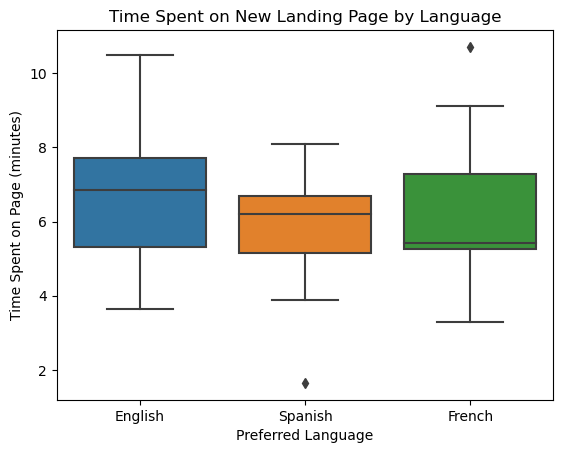

In [18]:
df_new = df[df['landing_page'] == 'new']
sns.boxplot(x='language_preferred', y='time_spent_on_the_page', data=df_new)
plt.title("Time Spent on New Landing Page by Language")
plt.xlabel("Preferred Language")
plt.ylabel("Time Spent on Page (minutes)")
plt.show()

### Step 1: Define the null and alternate hypotheses

𝐻0: The mean time spent on the new page is the same across different language users.

𝐻𝑎: At least one group's mean time spent on the new page is different from the others.

### Step 2: Select Appropriate test

Since we are comparing means across more than two groups based on their language preference, the appropriate statistical test is ANOVA (Analysis of Variance).

### Step 3: Decide the significance level

The significance level is set at  𝛼=0.05.

### Step 4: Collect and Prepare Data

In [19]:
time_spent_English = df_new[df_new['language_preferred'] == "English"]['time_spent_on_the_page']
time_spent_French = df_new[df_new['language_preferred'] == "French"]['time_spent_on_the_page']
time_spent_Spanish = df_new[df_new['language_preferred'] == "Spanish"]['time_spent_on_the_page']

### Step 5: Calculate the p-value

In [20]:
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(time_spent_English, time_spent_French, time_spent_Spanish)

### Step 6: Compare p-value with $\alpha$

In [21]:
if p_value < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Fail to reject the null hypothesis


### Step 7:  Draw inference

Given that we fail to reject the null hypothesis in our ANOVA test, it can be inferred that there is no significant difference in the time spent on the new landing page among users who prefer different languages. This suggests that the new page is equally engaging across English, French, and Spanish speakers, indicating that the redesign has been successful in creating a universally appealing experience. This uniformity in engagement levels across language preferences can be viewed as a positive outcome, as it implies that the landing page performs well across diverse demographic segments without bias.

## Conclusion and Business Recommendations

Conclusion
Through rigorous statistical analysis, we have established that:

User Engagement: Users spend significantly more time on the new landing page than on the existing one, suggesting higher engagement with the new design.
Conversion Rate: The conversion rate analysis indicates that the new landing page does not significantly outperform the old page in terms of converting users, suggesting that while the new design is engaging, it does not necessarily lead to higher conversion rates.
Language Preference and Conversion: There is no significant relationship between language preference and conversion, indicating that language alone does not influence the likelihood of conversion.
Time Spent by Language: The time spent on the new page is consistent across different language preferences, demonstrating the new design's universal appeal.
Business Recommendations
Continue Using the New Landing Page: Given its effectiveness in enhancing user engagement, it is recommended to continue using the new landing page. However, elements that could potentially increase conversion rates should be further explored and tested.

Optimize Conversion Strategies: Despite the new design's success in engagement, further optimization strategies focused on conversion should be implemented. This could include A/B testing specific call-to-action elements, optimizing page load times, or simplifying the subscription process.

Cultural Customization: Although language does not show a significant direct effect on conversion rates or time spent on the page, considering cultural nuances in content presentation and marketing messages could enhance user experience and potentially improve conversions indirectly.

Regular Testing and Updates: Continuously monitor and analyze user behavior on the landing page. Regular updates based on user feedback and behavior analytics should be implemented to keep the page effective and engaging.

Segmented Marketing Approaches: Even though language preference does not significantly affect conversion or engagement, segmented marketing approaches that tailor content to specific demographic and linguistic groups could help in addressing subtle preferences that might not be captured through broad analyses.

By following these recommendations, E-news Express can ensure that its landing page not only attracts but also effectively converts visitors into subscribers, enhancing overall business performance.

___